<a href="https://colab.research.google.com/github/Zeldano118/QPon_NLP_PBA/blob/main/assignments/week%203/2_week3_yearly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Reviews per Year Analysis — QPon
Based on Kaggle example (Indonesia Startup Apps Reviews), applied to QPon data.

**Input:** `df_qpon_rev.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
stop_words = set(stopwords.words('indonesian'))

In [2]:
from google.colab import files
uploaded = files.upload()

import io
for fn in uploaded.keys():
    df = pd.read_csv(io.BytesIO(uploaded[fn]))
    print(f'Loaded: {len(df):,} rows')
df.head()

Saving df_qpon_rev.csv to df_qpon_rev.csv
Loaded: 4,684 rows


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,85c1f968-1c50-4eb0-a84e-c4fdea4ac20d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,tidak bisa login (alasan aktivitas mencurigaka...,1,170,2.21.0.1,2026-01-11 13:44:34,NaN,NaN,2.21.0.1
1,36aaf78f-66de-4b14-9adc-21575d7a94a3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi log out dengan sendirinya, pas login ...",1,79,2.21.0.1,2026-01-16 05:05:27,NaN,NaN,2.21.0.1
2,9a0b398e-d7b1-4679-a4d4-97f7aa47f9f6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kapok deh Awal doang enak . sekarang2 mau orde...,1,37,2.21.0.1,2026-01-11 04:31:11,NaN,NaN,2.21.0.1
3,113779d5-cae5-49f7-b67d-1a885af6f1fc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,CS gak bisa ngebantu buat login karena masalah...,1,52,2.24.0.1,2026-02-21 04:07:01,NaN,NaN,2.24.0.1
4,1d499b55-883c-422c-a83e-0a181330fd97,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi banyak error. perkara ganti hape dibi...,1,2,2.24.0.1,2026-03-10 08:43:02,NaN,NaN,2.24.0.1


---
## Descriptive Statistics

/tmp/ipykernel_7523/942606851.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')


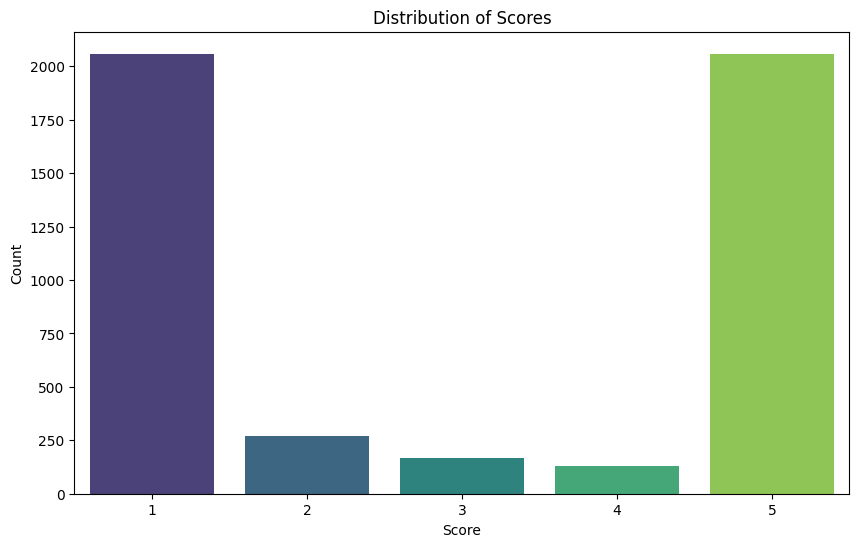

In [3]:
# score distribution
score_counts = df['score'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.barplot(x=score_counts.index, y=score_counts.values, palette='viridis')
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

---
## Reviews per Year

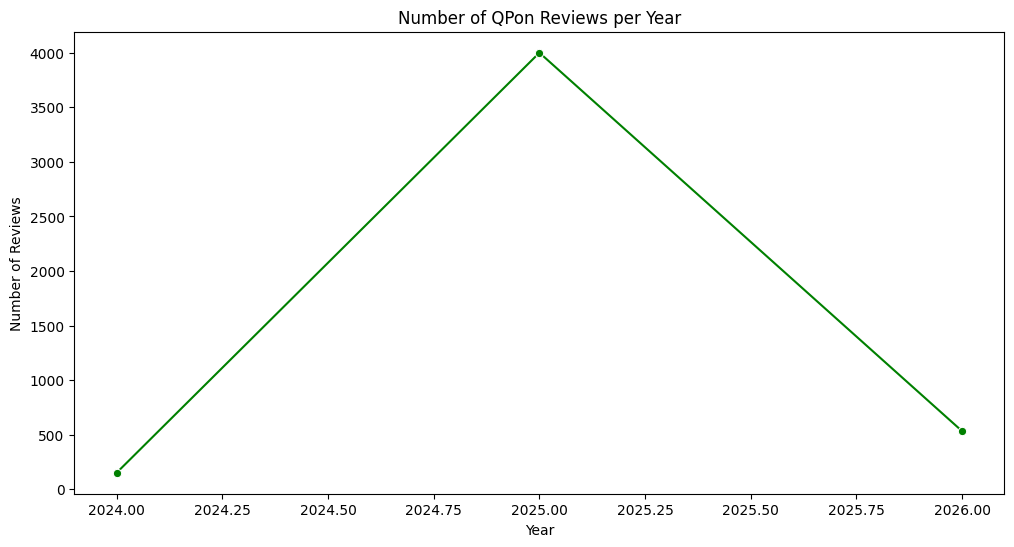

In [4]:
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year
year_counts = df['year'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='green')
plt.title('Number of QPon Reviews per Year')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.show()

---
## Score Distribution by Year

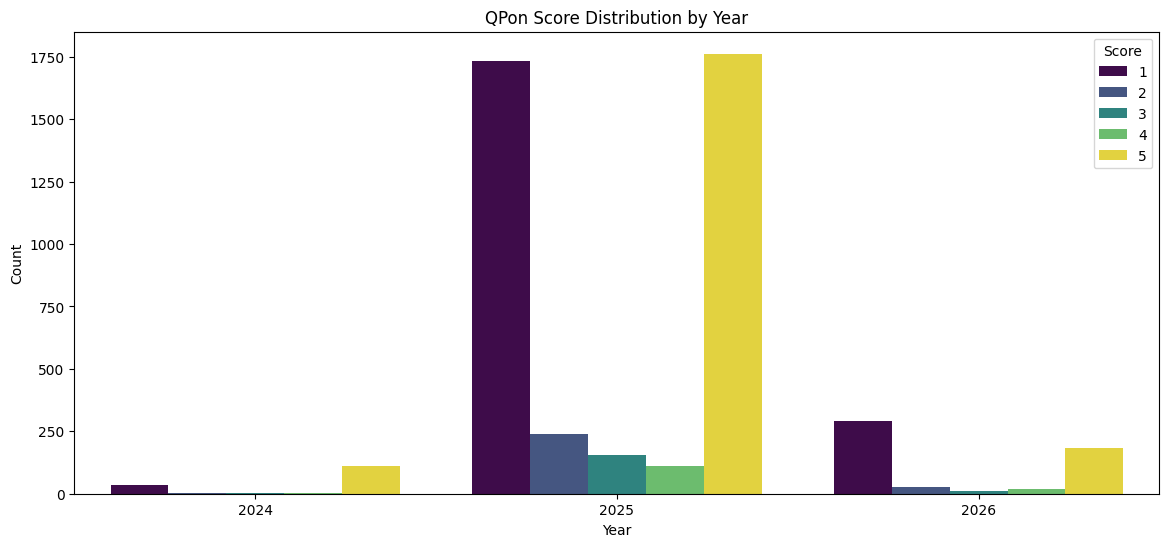

In [5]:
plt.figure(figsize=(14, 6))
sns.countplot(x='year', hue='score', data=df, palette='viridis')
plt.title('QPon Score Distribution by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Score')
plt.show()

---
## Word Cloud (Positive vs Negative)

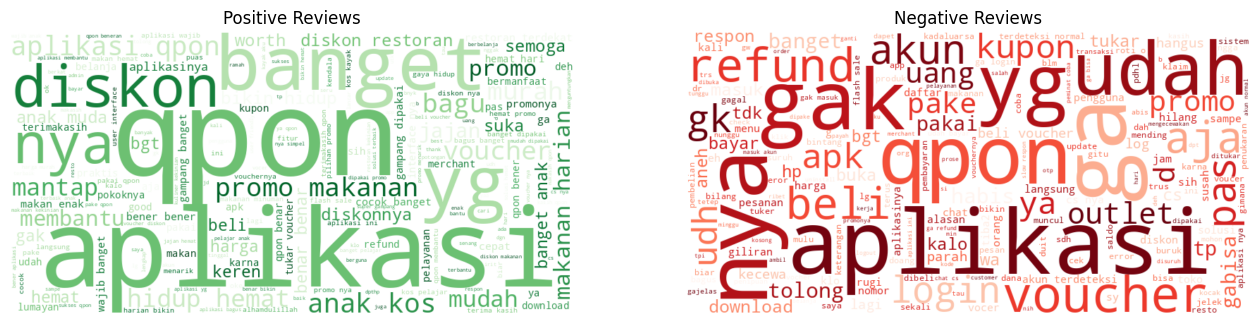

In [6]:
df['sentiment'] = df['score'].apply(lambda x: 'positive' if x >= 4 else ('negative' if x <= 2 else 'neutral'))

def remove_stopwords(text):
    words = str(text).lower().split()
    return ' '.join([w for w in words if w not in stop_words])

pos_text = ' '.join(df[df['sentiment'] == 'positive']['content'].dropna().apply(remove_stopwords))
neg_text = ' '.join(df[df['sentiment'] == 'negative']['content'].dropna().apply(remove_stopwords))

pos_wc = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(pos_text)
neg_wc = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(neg_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(pos_wc, interpolation='bilinear')
axes[0].set_title('Positive Reviews')
axes[0].axis('off')
axes[1].imshow(neg_wc, interpolation='bilinear')
axes[1].set_title('Negative Reviews')
axes[1].axis('off')
plt.show()